In [1]:
from finite_scalar_quantization import FSQ

import os
import torch
import torch.nn as nn
import tqdm
import numpy as np
from matplotlib import pyplot as plt

def resolve_nn_activation(act_name: str) -> torch.nn.Module:
    if act_name == "elu":
        return torch.nn.ELU()
    elif act_name == "selu":
        return torch.nn.SELU()
    elif act_name == "relu":
        return torch.nn.ReLU()
    elif act_name == "crelu":
        return torch.nn.CELU()
    elif act_name == "lrelu":
        return torch.nn.LeakyReLU()
    elif act_name == "tanh":
        return torch.nn.Tanh()
    elif act_name == "sigmoid":
        return torch.nn.Sigmoid()
    elif act_name == "identity":
        return torch.nn.Identity()
    else:
        raise ValueError(f"Invalid activation function '{act_name}'.")

In [2]:
class SONIC_FSQVAE(nn.Module):
    def __init__(self, 
                 fsqvae_latent_dim: int, 
                 fsq_levels: list[int],
                 num_codebooks: int,
                 robot_command_dim: int,
                 human_command_dim: int,
                 robot_encoder_dims: list[int],
                 human_encoder_dims: list[int],
                 robot_decoder_dims: list[int],
                 activation: str = "elu",
    ):
        super().__init__()
        activation_fn = resolve_nn_activation(activation)
        
        # robot encoder
        robot_encoder_layers = []
        robot_encoder_layers.append(nn.Linear(robot_command_dim, robot_encoder_dims[0]))
        robot_encoder_layers.append(activation_fn)
        for i in range(len(robot_encoder_dims) - 1):
            robot_encoder_layers.append(nn.Linear(robot_encoder_dims[i], robot_encoder_dims[i+1]))
            robot_encoder_layers.append(activation_fn)
        robot_encoder_layers.append(nn.Linear(robot_encoder_dims[-1], fsqvae_latent_dim))
        self.robot_encoder = nn.Sequential(*robot_encoder_layers)
        
        # human encoder
        human_encoder_layers = []
        human_encoder_layers.append(nn.Linear(human_command_dim, human_encoder_dims[0]))
        human_encoder_layers.append(activation_fn)
        for i in range(len(human_encoder_dims) - 1):
            human_encoder_layers.append(nn.Linear(human_encoder_dims[i], human_encoder_dims[i+1]))
            human_encoder_layers.append(activation_fn)
        human_encoder_layers.append(nn.Linear(human_encoder_dims[-1], fsqvae_latent_dim))
        self.human_encoder = nn.Sequential(*human_encoder_layers)
        
        self.fsq = FSQ(
            dim=fsqvae_latent_dim,
            levels=fsq_levels,
            num_codebooks=num_codebooks,
        )
        
        # decoder
        recover_layers = []
        recover_layers.append(nn.Linear(fsqvae_latent_dim, robot_decoder_dims[0]))
        recover_layers.append(activation_fn)
        for i in range(len(robot_decoder_dims) - 1):
            recover_layers.append(nn.Linear(robot_decoder_dims[i], robot_decoder_dims[i+1]))
            recover_layers.append(activation_fn)
        recover_layers.append(nn.Linear(robot_decoder_dims[-1], robot_command_dim))
        self.recover_decoder = nn.Sequential(*recover_layers)
        

In [3]:
# motion file
robot_npz_file = "../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/walk1_subject2.npz"
human_npz_file = "../../datasets/smplx_datasets/lafan1_smplx_datasets/train/walk1_subject2.npz"

robot_motion_data = np.load(robot_npz_file)
human_motion_data = np.load(human_npz_file)

robot_commands = torch.tensor(np.concatenate([robot_motion_data["joint_pos"], robot_motion_data["joint_vel"]], axis=-1), dtype=torch.float32)
human_commands = torch.tensor(human_motion_data["pose_body"], dtype=torch.float32)

# align lengths
min_length = min(robot_commands.shape[0], human_commands.shape[0])
robot_commands = robot_commands[:min_length]
human_commands = human_commands[:min_length]

# print shapes
print("robot_commands shape:", robot_commands.shape)
print("human_commands shape:", human_commands.shape)

# create future frames
offsets = 5 * torch.arange(10, dtype=torch.int32)
time_steps = torch.arange(min_length - 50, dtype=torch.int32).unsqueeze(1) + offsets.unsqueeze(0)
future_robot_commands = robot_commands[time_steps].flatten(start_dim=1)  # (T-50, 10xD) = 580
future_human_commands = human_commands[time_steps].flatten(start_dim=1)  # (T-50, 10xD) = 630

print("future_robot_commands shape:", future_robot_commands.shape)
print("future_human_commands shape:", future_human_commands.shape)

robot_commands shape: torch.Size([13065, 58])
human_commands shape: torch.Size([13065, 63])
future_robot_commands shape: torch.Size([13015, 580])
future_human_commands shape: torch.Size([13015, 630])


## step1: test robot_commands en-decoder

In [4]:
# define all hyperparameters
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
episode = 1000
batch_size = 1024

future_robot_commands = future_robot_commands.to(device)
future_human_commands = future_human_commands.to(device)

In [5]:
# create model and optimizer
model = SONIC_FSQVAE(
    fsqvae_latent_dim=64,
    fsq_levels=[8,8,8,5,5,5],
    num_codebooks=16,
    robot_command_dim=future_robot_commands.shape[1],
    human_command_dim=future_human_commands.shape[1],
    robot_encoder_dims=[512, 256],
    human_encoder_dims=[512, 256],
    robot_decoder_dims=[256, 512],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

100%|██████████| 1000/1000 [00:05<00:00, 175.54it/s]


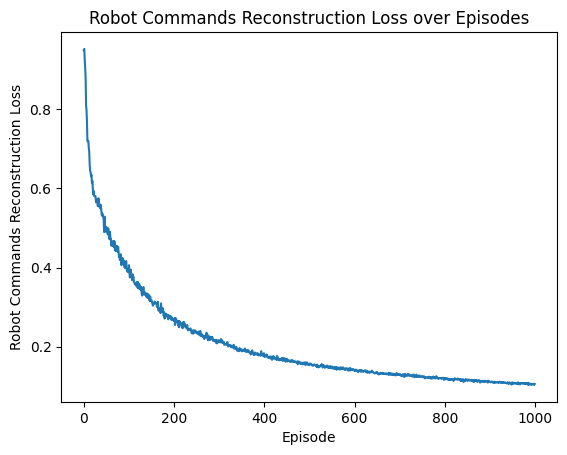

In [6]:
# optimization loop
# future_robot_commands -> robot_encoder -> fsq -> decoder -> recon_robot_commands

robot_commands_losses = []

for ep in tqdm.trange(episode):
    # random shuffle
    perm = torch.randperm(future_robot_commands.shape[0])
    batch_future_robot_commands = future_robot_commands[perm[:batch_size]]
    optimizer.zero_grad()
    
    # encode
    robot_latent = model.robot_encoder(batch_future_robot_commands)
    # quantize
    quantized_latent, _ = model.fsq(robot_latent)
    # decode
    recon_robot_commands = model.recover_decoder(quantized_latent)
    
    # compute loss
    loss = nn.functional.mse_loss(recon_robot_commands, batch_future_robot_commands)
    loss.backward()
    optimizer.step()

    robot_commands_losses.append(loss.item())

# plot loss
plt.plot(robot_commands_losses)
plt.xlabel("Episode")
plt.ylabel("Robot Commands Reconstruction Loss")
plt.title("Robot Commands Reconstruction Loss over Episodes")
plt.show()

## step2: scale datasets

In [7]:
# motion file
robot_npz_dir = "../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/"
human_npz_dir = "../../datasets/smplx_datasets/lafan1_smplx_datasets/train/"

# sort files in directories
robot_npz_files = sorted([os.path.join(robot_npz_dir, f) for f in os.listdir(robot_npz_dir) if f.endswith('.npz')])
human_npz_files = sorted([os.path.join(human_npz_dir, f) for f in os.listdir(human_npz_dir) if f.endswith('.npz')])

print("Robot NPZ files:", robot_npz_files)
print("Human NPZ files:", human_npz_files)
print("Number of Robot NPZ files:", len(robot_npz_files))
print("Number of Human NPZ files:", len(human_npz_files))

full_future_robot_commands = []
full_future_human_commands = []

for robot_npz_file, human_npz_file in zip(robot_npz_files, human_npz_files):
    assert os.path.basename(robot_npz_file) == os.path.basename(human_npz_file), "Mismatched robot and human npz files."
    robot_motion_data = np.load(robot_npz_file)
    human_motion_data = np.load(human_npz_file)

    robot_commands = torch.tensor(np.concatenate([robot_motion_data["joint_pos"], robot_motion_data["joint_vel"]], axis=-1), dtype=torch.float32)
    human_commands = torch.tensor(human_motion_data["pose_body"], dtype=torch.float32)

    # align lengths
    min_length = min(robot_commands.shape[0], human_commands.shape[0])
    robot_commands = robot_commands[:min_length]
    human_commands = human_commands[:min_length]

    # create future frames
    offsets = 5 * torch.arange(10, dtype=torch.int32)
    time_steps = torch.arange(min_length - 50, dtype=torch.int32).unsqueeze(1) + offsets.unsqueeze(0)
    future_robot_commands = robot_commands[time_steps].flatten(start_dim=1)  # (T-50, 10xD)
    future_human_commands = human_commands[time_steps].flatten(start_dim=1)  # (T-50, 10xD)

    full_future_robot_commands.append(future_robot_commands)
    full_future_human_commands.append(future_human_commands)
    
future_robot_commands = torch.cat(full_future_robot_commands, dim=0).to(device)
future_human_commands = torch.cat(full_future_human_commands, dim=0).to(device)

print("Full future_robot_commands shape:", future_robot_commands.shape)
print("Full future_human_commands shape:", future_human_commands.shape)

Robot NPZ files: ['../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance1_subject1.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance1_subject2.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance1_subject3.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance2_subject1.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance2_subject2.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance2_subject3.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance2_subject4.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/dance2_subject5.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/fallAndGetUp1_subject1.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/fallAndGetUp1_subject4.npz', '../../datasets//npz_datasets/LAFAN1_Retargeting_Dataset/g1/train/fallAndGetUp1_subject5

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:47<00:00, 42.25it/s]


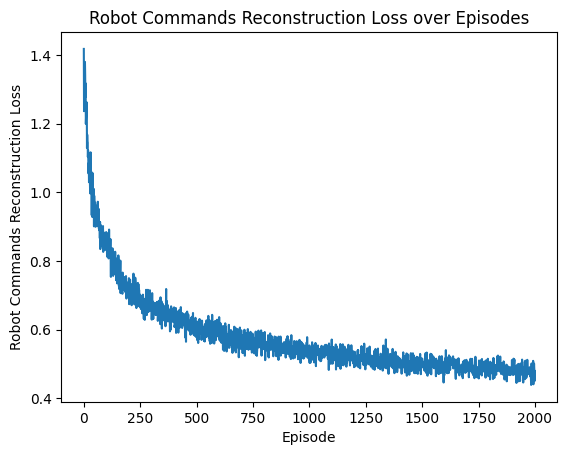

In [8]:
episode = 2000
batch_size = 1024

# create model and optimizer
model = SONIC_FSQVAE(
    fsqvae_latent_dim=64,
    fsq_levels=[8,8,8,5,5,5],
    num_codebooks=12,
    robot_command_dim=future_robot_commands.shape[1],
    human_command_dim=future_human_commands.shape[1],
    robot_encoder_dims=[512, 256],
    human_encoder_dims=[512, 256],
    robot_decoder_dims=[256, 512],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# optimization loop
# future_robot_commands -> robot_encoder -> fsq -> decoder -> recon_robot_commands

robot_commands_losses = []

for ep in tqdm.trange(episode):
    # random shuffle
    perm = torch.randperm(future_robot_commands.shape[0])
    batch_future_robot_commands = future_robot_commands[perm[:batch_size]]
    optimizer.zero_grad()
    
    # encode
    robot_latent = model.robot_encoder(batch_future_robot_commands)
    # quantize
    quantized_latent, _ = model.fsq(robot_latent)
    # decode
    recon_robot_commands = model.recover_decoder(quantized_latent)
    
    # compute loss
    loss = nn.functional.mse_loss(recon_robot_commands, batch_future_robot_commands)
    loss.backward()
    optimizer.step()

    robot_commands_losses.append(loss.item())
    
# plot loss
plt.plot(robot_commands_losses)
plt.xlabel("Episode")
plt.ylabel("Robot Commands Reconstruction Loss")
plt.title("Robot Commands Reconstruction Loss over Episodes")
plt.show()

## Step3: Scale Model

In [9]:
episode = 50000
batch_size = 8192

# create model and optimizer
model = SONIC_FSQVAE(
    fsqvae_latent_dim=128,
    fsq_levels=[8,8,8,5,5,5],
    num_codebooks=32,
    robot_command_dim=future_robot_commands.shape[1],
    human_command_dim=future_human_commands.shape[1],
    robot_encoder_dims=[1024, 512, 256],
    human_encoder_dims=[1024, 512, 256],
    robot_decoder_dims=[256, 512, 1024],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# optimization loop
# future_robot_commands -> robot_encoder -> fsq -> decoder -> recon_robot_commands

robot_commands_losses = []

for ep in tqdm.trange(episode):
    # random shuffle
    perm = torch.randperm(future_robot_commands.shape[0])
    batch_future_robot_commands = future_robot_commands[perm[:batch_size]]
    batch_future_smplx_commands = future_human_commands[perm[:batch_size]]
    optimizer.zero_grad()
    
    # encode
    h_sr = model.robot_encoder(batch_future_robot_commands)
    h_sh = model.human_encoder(batch_future_smplx_commands)
    # quantize
    z_sr, _ = model.fsq(h_sr)
    z_sh, _ = model.fsq(h_sh)
    # decode
    hat_sr = model.recover_decoder(z_sr) # dim: robot
    hat_sh = model.recover_decoder(z_sh) # dim: robot
    
    # compute loss
    loss_recon1 = nn.functional.mse_loss(hat_sr, batch_future_robot_commands)
    loss_recon2 = nn.functional.mse_loss(hat_sh, batch_future_robot_commands)
    loss_token = nn.functional.mse_loss(z_sr, z_sh)
    
    # cycle encode
    h_hat_sh = model.robot_encoder(hat_sh)
    z_hat_sh, _ = model.fsq(h_hat_sh)
    loss_cycle = nn.functional.mse_loss(z_hat_sh, z_sr)
    
    loss = loss_recon1 + loss_recon2 + loss_token + loss_cycle
    
    loss.backward()
    optimizer.step()

    robot_commands_losses.append([loss_recon1.item(), loss_recon2.item(), loss_token.item(), loss_cycle.item()])

100%|██████████| 50000/50000 [24:44<00:00, 33.68it/s]


In [10]:
# save model 
torch.save(model.state_dict(), "/tmp/pretrain_fsqvae.pth")

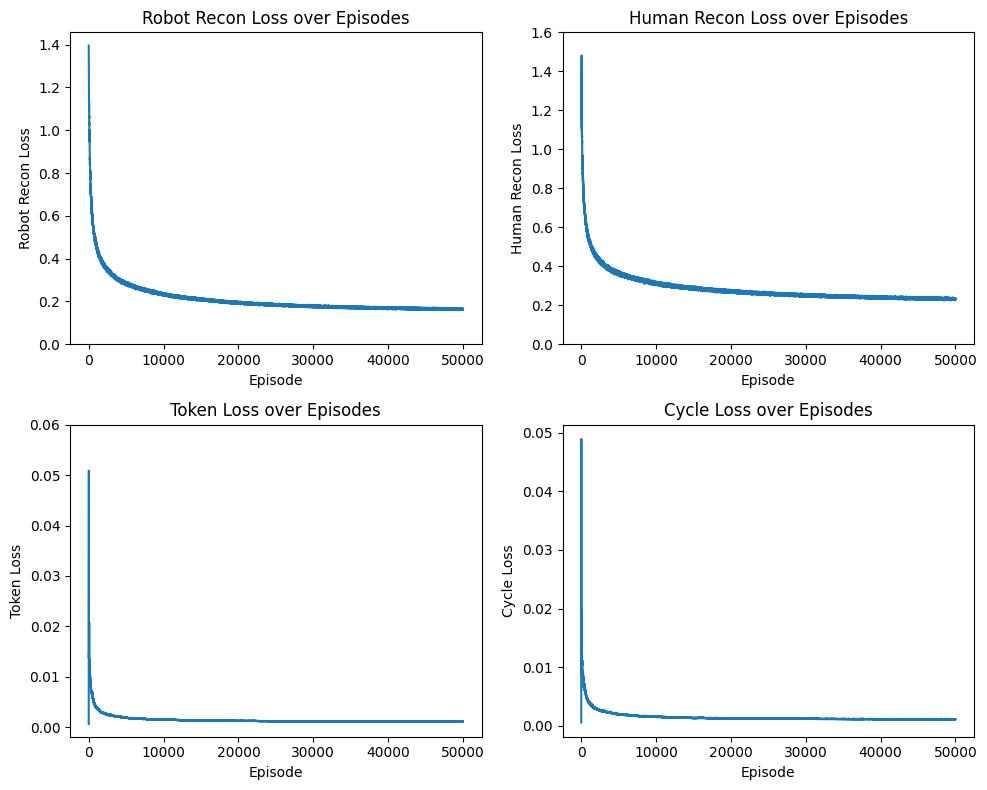

In [11]:
# subplot loss
plt.figure(figsize=(10,8))
plt.subplot(2, 2, 1)
plt.plot([l[0] for l in robot_commands_losses])
plt.xlabel("Episode")
plt.ylabel("Robot Recon Loss")
plt.yticks(np.arange(0, max([l[0] for l in robot_commands_losses])+0.2, 0.2))
plt.title("Robot Recon Loss over Episodes")

plt.subplot(2, 2, 2)
plt.plot([l[1] for l in robot_commands_losses])
plt.xlabel("Episode")
plt.ylabel("Human Recon Loss")
plt.yticks(np.arange(0, max([l[1] for l in robot_commands_losses])+0.2, 0.2))
plt.title("Human Recon Loss over Episodes")

plt.subplot(2, 2, 3)
plt.plot([l[2] for l in robot_commands_losses])
plt.xlabel("Episode")
plt.ylabel("Token Loss")
plt.yticks(np.arange(0, max([l[2] for l in robot_commands_losses])+0.01, 0.01))
plt.title("Token Loss over Episodes")

plt.subplot(2, 2, 4)
plt.plot([l[3] for l in robot_commands_losses])
plt.xlabel("Episode")
plt.ylabel("Cycle Loss")
plt.yticks(np.arange(0, max([l[3] for l in robot_commands_losses])+0.01, 0.01))
plt.title("Cycle Loss over Episodes")
plt.tight_layout()
plt.show()

## Step4: load pretrain fsqvae

In [ ]:
import mujoco
import matplotlib.pyplot as plt
import numpy as np
import tqdm

xml_path = "/path/to/unitree_g1/g1_mocap_29dof.xml"

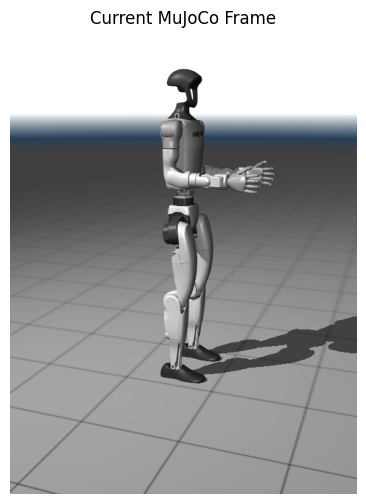

In [13]:
mj_model = mujoco.MjModel.from_xml_path(xml_path)
mj_data = mujoco.MjData(mj_model)

renderer = mujoco.Renderer(mj_model, height=640, width=480)
cam = mujoco.MjvCamera()
cam.azimuth = 110 
cam.elevation = -15
cam.distance = 2.5
cam.lookat[:] = [0.0, 0.0, 0.5]


mujoco.mj_step(mj_model, mj_data)
renderer.update_scene(mj_data, camera=cam)
frame = renderer.render()

plt.figure(figsize=(8, 6))
plt.imshow(frame)
plt.axis('off')
plt.title('Current MuJoCo Frame')
plt.show()

In [14]:
mj_joint_names =  ['left_hip_pitch_joint', 'left_hip_roll_joint', 'left_hip_yaw_joint',
                'left_knee_joint', 
                'left_ankle_pitch_joint', 'left_ankle_roll_joint', 
                'right_hip_pitch_joint', 'right_hip_roll_joint', 'right_hip_yaw_joint',
                'right_knee_joint',
                'right_ankle_pitch_joint', 'right_ankle_roll_joint',
                'waist_yaw_joint', 'waist_roll_joint', 'waist_pitch_joint',
                'left_shoulder_pitch_joint', 'left_shoulder_roll_joint', 'left_shoulder_yaw_joint',
                'left_elbow_joint',
                'left_wrist_roll_joint', 'left_wrist_pitch_joint', 'left_wrist_yaw_joint',
                'right_shoulder_pitch_joint', 'right_shoulder_roll_joint', 'right_shoulder_yaw_joint',
                'right_elbow_joint',
                'right_wrist_roll_joint', 'right_wrist_pitch_joint', 'right_wrist_yaw_joint']
lab_joint_names = ['left_hip_pitch_joint', 
                        'right_hip_pitch_joint', 
                        'waist_yaw_joint', 
                        'left_hip_roll_joint', 
                        'right_hip_roll_joint', 
                        'waist_roll_joint', 
                        'left_hip_yaw_joint', 
                        'right_hip_yaw_joint', 
                        'waist_pitch_joint', 
                        'left_knee_joint', 
                        'right_knee_joint', 
                        'left_shoulder_pitch_joint', 
                        'right_shoulder_pitch_joint', 
                        'left_ankle_pitch_joint', 
                        'right_ankle_pitch_joint', 
                        'left_shoulder_roll_joint', 
                        'right_shoulder_roll_joint', 
                        'left_ankle_roll_joint', 
                        'right_ankle_roll_joint', 
                        'left_shoulder_yaw_joint', 
                        'right_shoulder_yaw_joint', 
                        'left_elbow_joint', 
                        'right_elbow_joint', 
                        'left_wrist_roll_joint', 
                        'right_wrist_roll_joint', 
                        'left_wrist_pitch_joint', 
                        'right_wrist_pitch_joint', 
                        'left_wrist_yaw_joint', 
                        'right_wrist_yaw_joint']

mj2lab = [mj_joint_names.index(joint) for joint in lab_joint_names]

In [15]:
ckpt_path = "../../checkpoints/pretrain_fsqvae.pth"

# create model and optimizer
model = SONIC_FSQVAE(
    fsqvae_latent_dim=128,
    fsq_levels=[8,8,8,5,5,5],
    num_codebooks=32,
    robot_command_dim=future_robot_commands.shape[1],
    human_command_dim=future_human_commands.shape[1],
    robot_encoder_dims=[1024, 512, 256],
    human_encoder_dims=[1024, 512, 256],
    robot_decoder_dims=[256, 512, 1024],
).to(device)

model.load_state_dict(torch.load(ckpt_path))

<All keys matched successfully>

In [16]:
sample_dict = {}
N = 100
# random sample one robot command
select_idx = torch.randint(0, future_robot_commands.shape[0], (N,))
sample_robot_command = future_robot_commands[select_idx]  # (10, D)
sample_human_command = future_human_commands[select_idx] 
print(f"{sample_robot_command.shape=}, {sample_human_command.shape=}")

# reshape
sample_robot_command_data = sample_robot_command.reshape(N, 10, -1)
sample_human_command_data = sample_human_command.reshape(N, 10, -1)
print(f"{sample_robot_command_data.shape=}, {sample_human_command_data.shape=}")

sample_dict["robot_command"] = sample_robot_command_data.cpu().numpy()
# sample_dict["human_command"] = sample_human_command_data.cpu().numpy()

with torch.no_grad():
    recon_sample_robot_commands = model.recover_decoder(model.fsq(model.robot_encoder(sample_robot_command.to(device)))[0])
    recon_sample_human_commands = model.recover_decoder(model.fsq(model.human_encoder(sample_human_command.to(device)))[0])
    
print(f"{recon_sample_robot_commands.shape=}, {recon_sample_human_commands.shape=}")
recon_sample_robot_commands_data = recon_sample_robot_commands.reshape(N, 10, -1)
recon_sample_human_commands_data = recon_sample_human_commands.reshape(N, 10, -1)
print(f"{recon_sample_robot_commands_data.shape=}, {recon_sample_human_commands_data.shape=}")

sample_dict["recon_robot_command"] = recon_sample_robot_commands_data.cpu().numpy()
sample_dict["recon_human_command"] = recon_sample_human_commands_data.cpu().numpy()

np.save("/tmp/sample_commands.npy", sample_dict)

sample_robot_command.shape=torch.Size([100, 580]), sample_human_command.shape=torch.Size([100, 630])
sample_robot_command_data.shape=torch.Size([100, 10, 58]), sample_human_command_data.shape=torch.Size([100, 10, 63])
recon_sample_robot_commands.shape=torch.Size([100, 580]), recon_sample_human_commands.shape=torch.Size([100, 580])
recon_sample_robot_commands_data.shape=torch.Size([100, 10, 58]), recon_sample_human_commands_data.shape=torch.Size([100, 10, 58])


In [17]:
data_dict = np.load("/tmp/sample_commands.npy", allow_pickle=True).item()
data_dict.keys()

print(data_dict["robot_command"].shape) 
print(data_dict["recon_robot_command"].shape) 
print(data_dict["recon_human_command"].shape) 
N = data_dict["robot_command"].shape[0]

sample_vis = []

for idx in tqdm.trange(N):
    frame_vis = {}
    for key, value in data_dict.items():
        frame_list = []
        for i in range(10):
            mj_data.qpos[7:][mj2lab] = value[idx, i, :29]
            mujoco.mj_forward(mj_model, mj_data)
            renderer.update_scene(mj_data, camera=cam)
            frame = renderer.render()
            frame_list.append(frame)

        total_frame = np.concatenate(frame_list, axis=1)
        frame_vis[key] = total_frame
    
    
    vis_frame = np.concatenate([frame_vis[key] for key in frame_vis], axis=0)
    sample_vis.append(vis_frame)
    

(100, 10, 58)
(100, 10, 58)
(100, 10, 58)


100%|██████████| 100/100 [00:17<00:00,  5.65it/s]


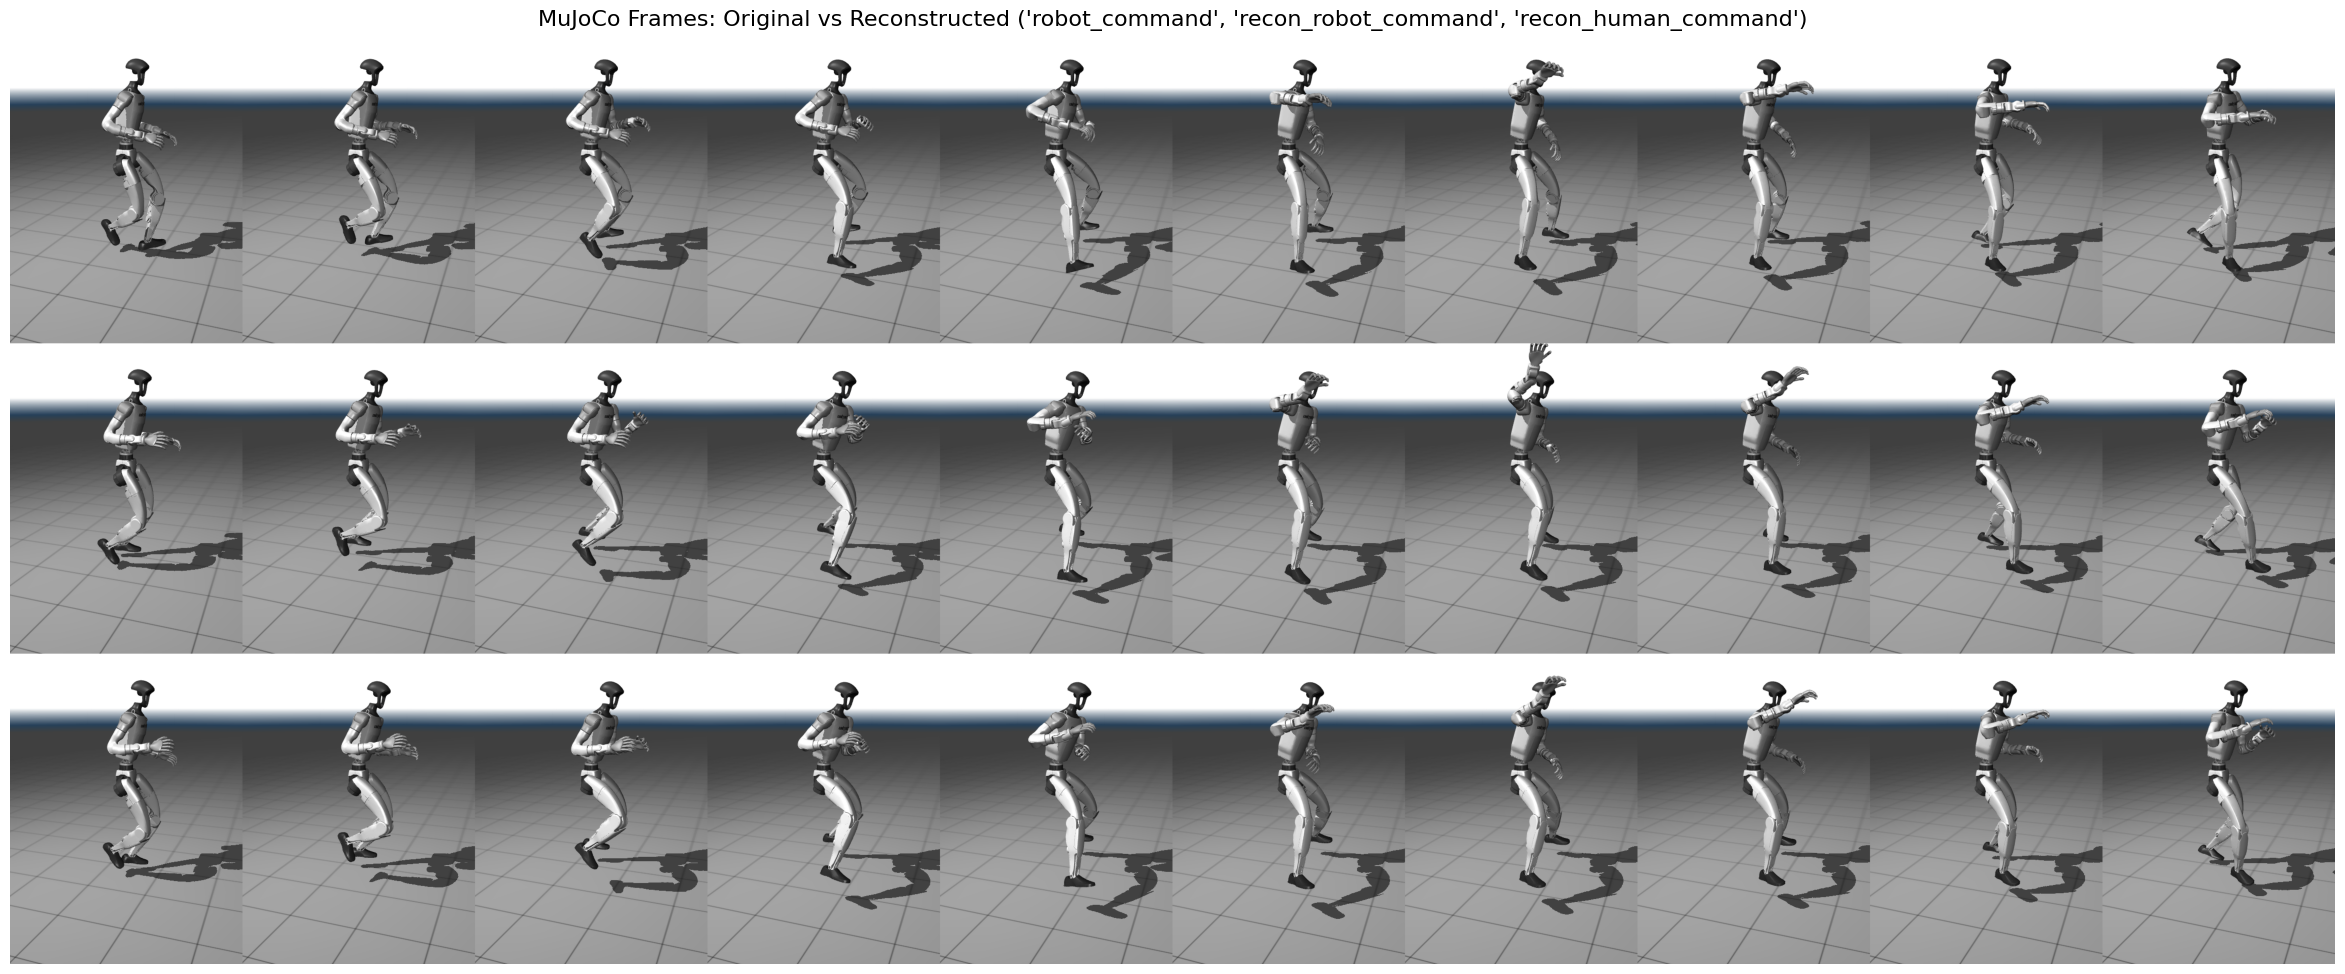

In [18]:
names = "'robot_command', 'recon_robot_command', 'recon_human_command'"
plt.figure(figsize=(30, 24))
plt.imshow(sample_vis[1])
plt.axis('off')
plt.title(f'MuJoCo Frames: Original vs Reconstructed ({names})', fontsize=16)
plt.show()